Cell 1 — Import Libraries


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


Cell 2 — Data Preprocessing


In [7]:
from torch.utils.data import DataLoader, Subset

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

print("Loading CIFAR-10 dataset...")
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Use only 10,000 training samples and 2,000 test samples to speed things up
train_dataset = Subset(train_dataset, range(10000))
test_dataset  = Subset(test_dataset, range(2000))

batch_size   = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples : {len(train_dataset)}")
print(f"Testing samples  : {len(test_dataset)}")

Loading CIFAR-10 dataset...
Training samples : 10000
Testing samples  : 2000


Cell 3 — Visualize Sample Images


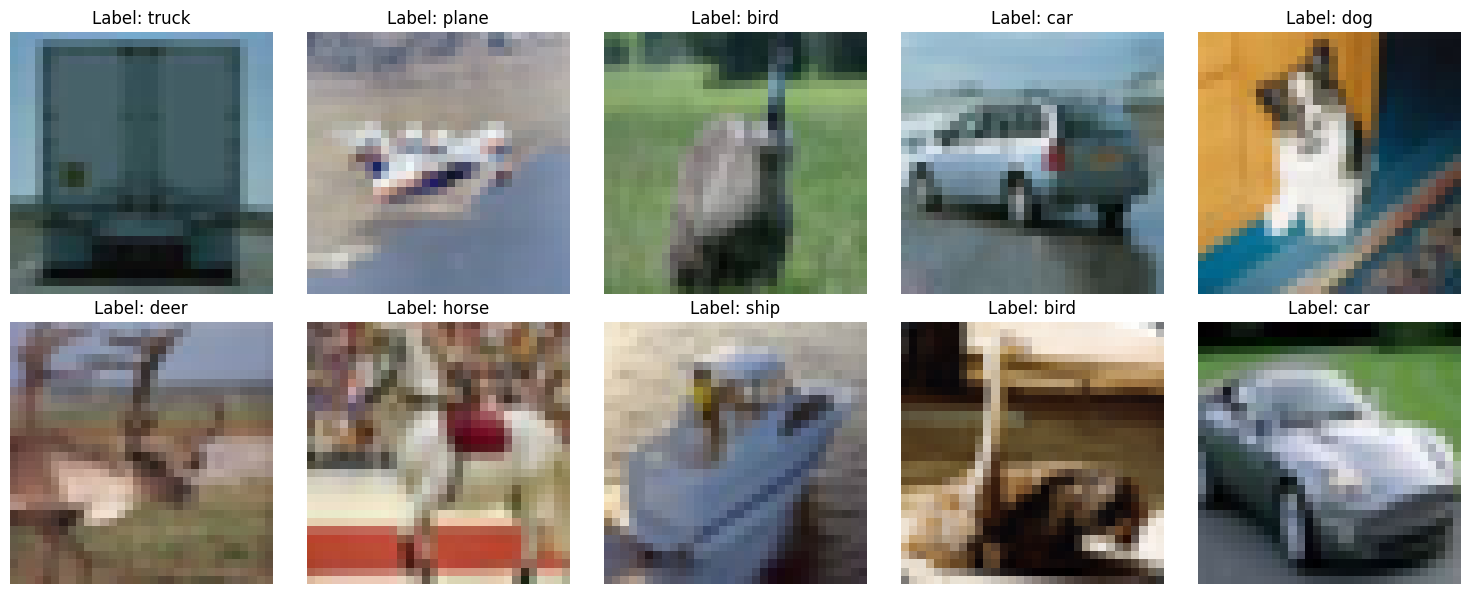

In [8]:
def show_images(loader, num_images=10):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    images = images[:num_images]
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    images = images * std + mean

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for idx in range(num_images):
        img = images[idx].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[idx].imshow(img)
        axes[idx].set_title(f'Label: {classes[labels[idx]]}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

show_images(train_loader)

Cell 4 — CNN Model


In [9]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # After 2 pooling layers: 32x32 -> 16x16 -> 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CNNModel().to(device)
print(model)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params:,}")

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Trainable Parameters: 1,070,794


Cell 5 — Model Training


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss    = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += target.size(0)
        correct      += predicted.eq(target).sum().item()

    return running_loss / len(train_loader), 100. * correct / total


def validate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs      = model(data)
            loss         = criterion(outputs, target)

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += target.size(0)
            correct      += predicted.eq(target).sum().item()

    return running_loss / len(test_loader), 100. * correct / total


num_epochs       = 10
train_losses     = []
train_accuracies = []
val_losses       = []
val_accuracies   = []

print("TRAINING STARTED")
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

TRAINING STARTED
Epoch [1/10] | Train Loss: 1.6922, Train Acc: 38.08% | Val Loss: 1.4421, Val Acc: 48.50%
Epoch [2/10] | Train Loss: 1.3556, Train Acc: 50.44% | Val Loss: 1.3083, Val Acc: 52.85%
Epoch [3/10] | Train Loss: 1.1920, Train Acc: 56.74% | Val Loss: 1.1780, Val Acc: 58.90%
Epoch [4/10] | Train Loss: 1.0698, Train Acc: 61.98% | Val Loss: 1.1535, Val Acc: 60.15%
Epoch [5/10] | Train Loss: 0.9741, Train Acc: 65.17% | Val Loss: 1.0488, Val Acc: 63.40%
Epoch [6/10] | Train Loss: 0.8873, Train Acc: 68.40% | Val Loss: 1.0646, Val Acc: 60.90%
Epoch [7/10] | Train Loss: 0.8120, Train Acc: 71.32% | Val Loss: 1.0071, Val Acc: 64.25%
Epoch [8/10] | Train Loss: 0.7612, Train Acc: 73.18% | Val Loss: 1.0379, Val Acc: 64.70%
Epoch [9/10] | Train Loss: 0.6794, Train Acc: 75.53% | Val Loss: 1.0308, Val Acc: 65.15%
Epoch [10/10] | Train Loss: 0.6142, Train Acc: 77.97% | Val Loss: 0.9959, Val Acc: 66.85%

Training completed in 198.72 seconds


Cell 6 — Evaluation and Confusion Matrix


Test Accuracy: 66.85%
Correct Predictions: 1337/2000

Classification Report:
              precision    recall  f1-score   support

       plane     0.7121    0.7194    0.7157       196
         car     0.7884    0.7525    0.7700       198
        bird     0.4975    0.5179    0.5075       195
         cat     0.5576    0.4623    0.5055       199
        deer     0.5648    0.6162    0.5894       198
         dog     0.5431    0.5784    0.5602       185
        frog     0.7681    0.7361    0.7518       216
       horse     0.7354    0.7202    0.7277       193
        ship     0.8402    0.7512    0.7932       217
       truck     0.6777    0.8079    0.7371       203

    accuracy                         0.6685      2000
   macro avg     0.6685    0.6662    0.6658      2000
weighted avg     0.6719    0.6685    0.6686      2000



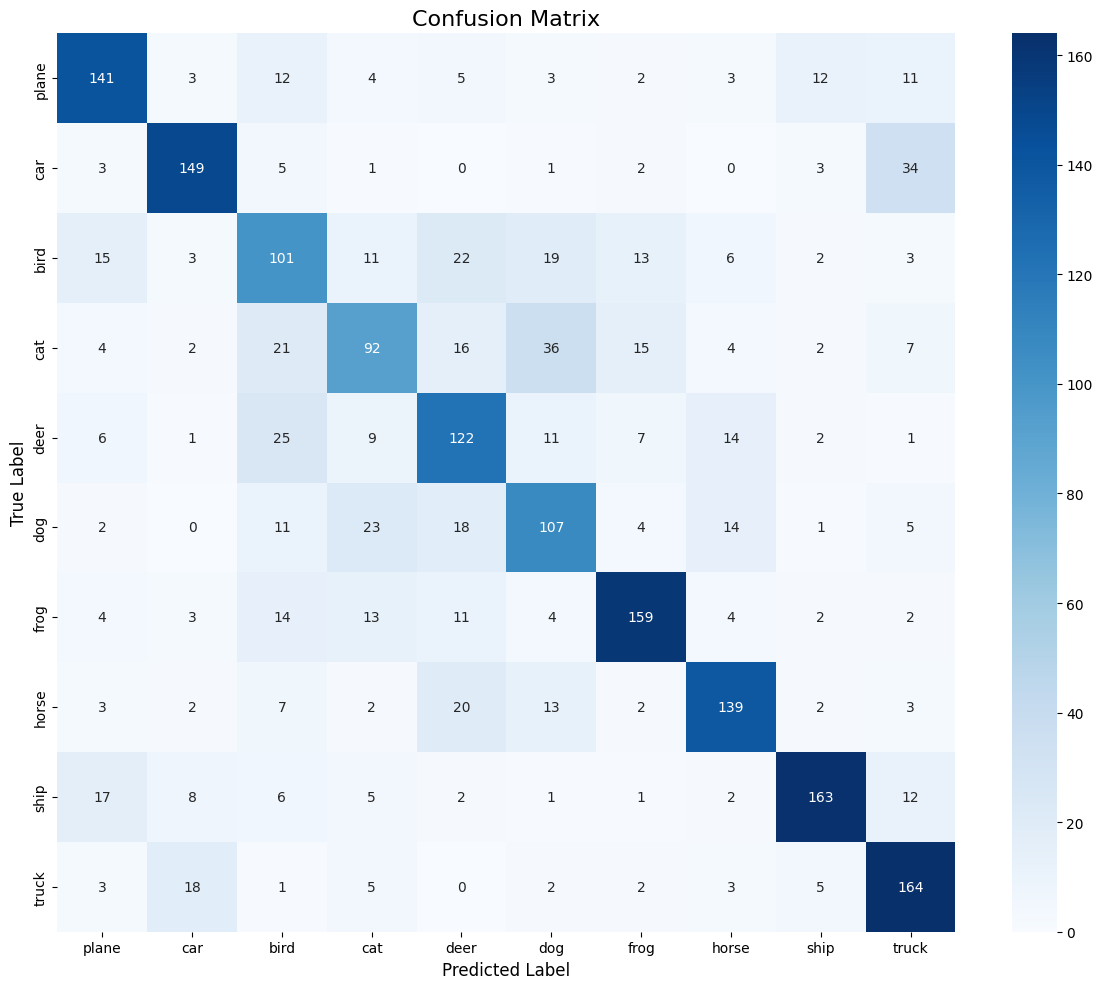

In [11]:
def evaluate_model(model, test_loader, device, classes):
    model.eval()
    all_predictions = []
    all_labels      = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs      = model(data)
            _, predicted = outputs.max(1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            total   += target.size(0)
            correct += predicted.eq(target).sum().item()

    accuracy = 100. * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Correct Predictions: {correct}/{total}\n")
    print("Classification Report:")
    print(classification_report(all_labels, all_predictions, target_names=classes, digits=4))

    return accuracy, confusion_matrix(all_labels, all_predictions)

test_accuracy, conf_matrix = evaluate_model(model, test_loader, device, classes)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

Cell 7 — Visualization (Accuracy and Loss Curves)


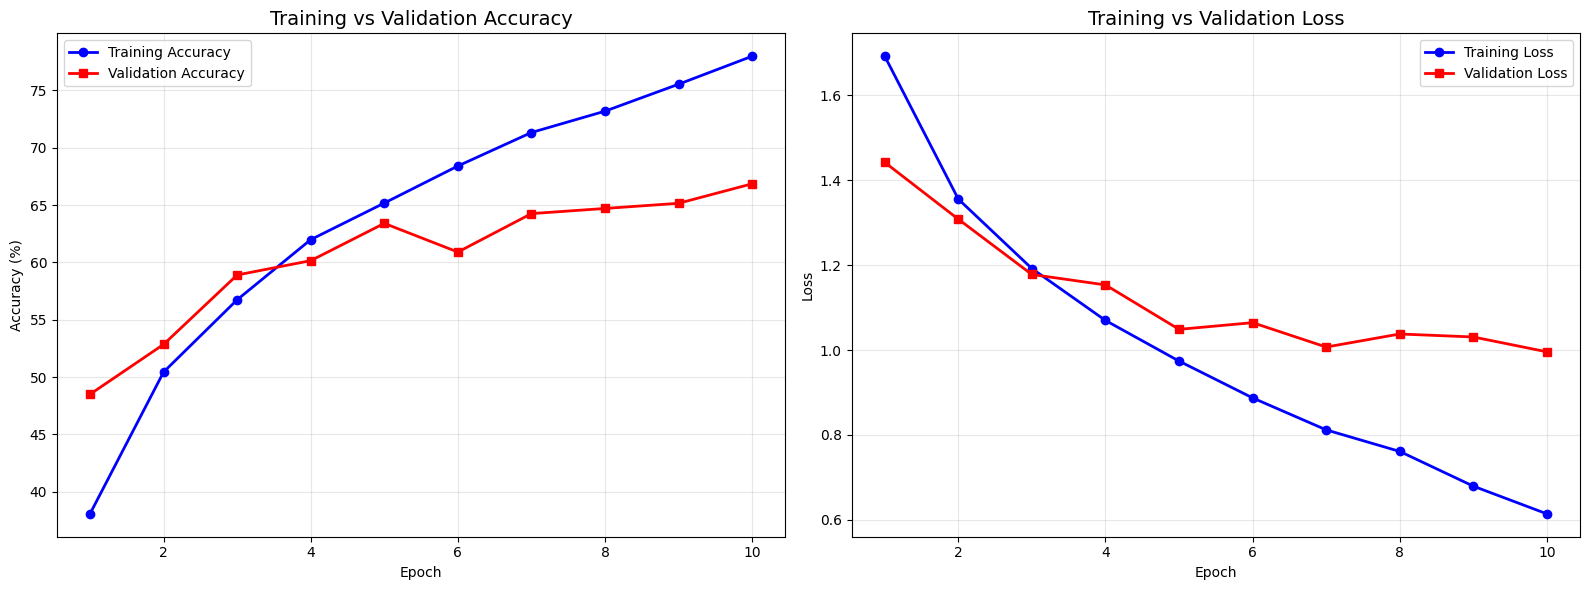

Final Training Accuracy : 77.97%
Final Validation Accuracy: 66.85%
Best Validation Accuracy : 66.85% at Epoch 10


In [12]:
epochs_range = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs_range, train_accuracies, 'b-o', label='Training Accuracy', linewidth=2)
ax1.plot(epochs_range, val_accuracies,   'r-s', label='Validation Accuracy', linewidth=2)
ax1.set_title('Training vs Validation Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_losses, 'b-o', label='Training Loss', linewidth=2)
ax2.plot(epochs_range, val_losses,   'r-s', label='Validation Loss', linewidth=2)
ax2.set_title('Training vs Validation Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy : {train_accuracies[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Best Validation Accuracy : {max(val_accuracies):.2f}% at Epoch {val_accuracies.index(max(val_accuracies))+1}")

Cell 8 — Sample Predictions


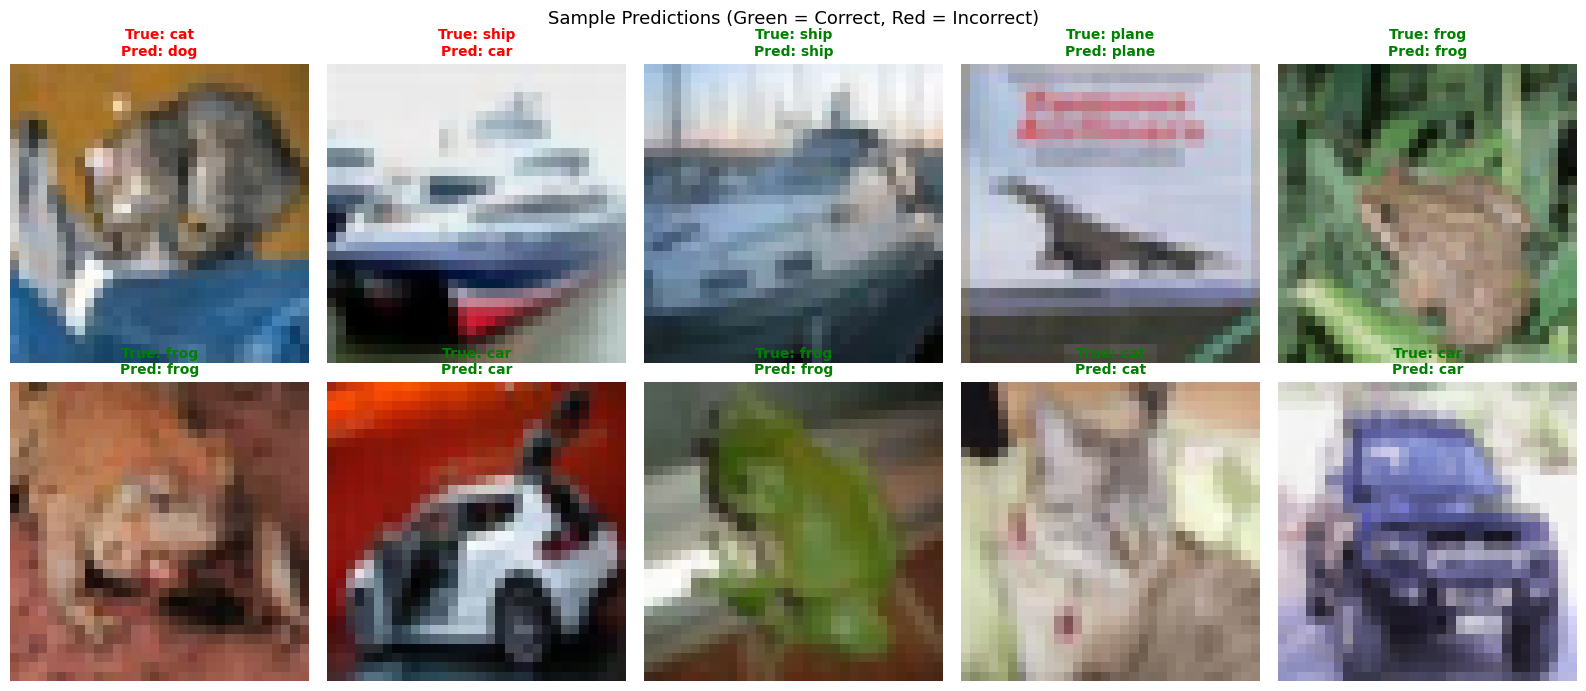

In [13]:
def visualize_predictions(model, test_loader, device, classes, num_images=10):
    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        _, predictions = model(images).max(1)

    images      = images.cpu()
    labels      = labels.cpu()
    predictions = predictions.cpu()

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    images = images * std + mean

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.ravel()

    for idx in range(num_images):
        img   = np.clip(images[idx].permute(1, 2, 0).numpy(), 0, 1)
        color = 'green' if labels[idx] == predictions[idx] else 'red'
        axes[idx].imshow(img)
        axes[idx].set_title(f'True: {classes[labels[idx]]}\nPred: {classes[predictions[idx]]}',
                            color=color, fontweight='bold', fontsize=10)
        axes[idx].axis('off')

    plt.suptitle('Sample Predictions (Green = Correct, Red = Incorrect)', fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, device, classes)

Cell 9 — Analysis


In [14]:
train_val_gap  = train_accuracies[-1] - val_accuracies[-1]
best_val_epoch = val_accuracies.index(max(val_accuracies)) + 1

print("1. Role of Convolution Layers")
print("-"*60)
print("""
Convolutional layers extract spatial features using learnable filters.
- Early layers detect simple features like edges and colors.
- Deeper layers combine these into complex patterns like shapes and objects.
- Parameter sharing means the same filter scans the whole image,
  reducing parameters and enabling position-independent detection.
""")

print("2. Why is Pooling Used?")
print("-"*60)
print("""
Pooling reduces the spatial size of feature maps.
- Lowers computation and memory usage.
- Makes the model less sensitive to small shifts in the image.
- Max pooling keeps only the strongest activation in each region,
  helping focus on the most important features.
""")

print("3. What Happens if We Increase the Number of Filters?")
print("-"*60)
print(f"""
More filters allow the model to detect more diverse features.
- Benefits: richer representation, potentially higher accuracy.
- Drawbacks: more parameters, longer training, risk of overfitting.
- In this model filters increase progressively: 32 -> 64 -> 128
- Total trainable parameters: {trainable_params:,}
""")

print("4. Overfitting in CNN - Did It Occur?")
print("-"*60)
print(f"""
Overfitting is when a model performs well on training data but
poorly on unseen data.

Final Training Accuracy : {train_accuracies[-1]:.2f}%
Final Validation Accuracy: {val_accuracies[-1]:.2f}%
Accuracy Gap             : {train_val_gap:.2f}%
Best Validation Epoch    : {best_val_epoch}/{num_epochs}

Verdict: {'Mild overfitting detected.' if train_val_gap > 5 else 'Model generalizes well, no significant overfitting.'}

Prevention techniques used in this model:
- Dropout (0.5) after fully connected layers
- Batch Normalization after each conv layer
- Data Augmentation (random flips and crops)
- Learning Rate Scheduling (ReduceLROnPlateau)
""")

1. Role of Convolution Layers
------------------------------------------------------------

Convolutional layers extract spatial features using learnable filters.
- Early layers detect simple features like edges and colors.
- Deeper layers combine these into complex patterns like shapes and objects.
- Parameter sharing means the same filter scans the whole image,
  reducing parameters and enabling position-independent detection.

2. Why is Pooling Used?
------------------------------------------------------------

Pooling reduces the spatial size of feature maps.
- Lowers computation and memory usage.
- Makes the model less sensitive to small shifts in the image.
- Max pooling keeps only the strongest activation in each region,
  helping focus on the most important features.

3. What Happens if We Increase the Number of Filters?
------------------------------------------------------------

More filters allow the model to detect more diverse features.
- Benefits: richer representation, 

Cell 10 — Save Model


In [15]:
torch.save(model.state_dict(), 'cnn_cifar10_model.pth')
print("Model weights saved as 'cnn_cifar10_model.pth'")

torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies,
}, 'cnn_cifar10_checkpoint.pth')
print("Full checkpoint saved as 'cnn_cifar10_checkpoint.pth'")

Model weights saved as 'cnn_cifar10_model.pth'
Full checkpoint saved as 'cnn_cifar10_checkpoint.pth'
